# Dendritic Cell Algorithm with Optimised Parameters Using Genetic Algorithm

This notebook implements the Dendritic Cell Algorithm (DCA) with Genetic Algorithm (GA) optimization for network intrusion detection, based on the research paper "Dendritic Cell Algorithm with Optimised Parameters Using Genetic Algorithm".

## 📋 Overview

- **DCA**: Bio-inspired classification algorithm based on danger theory
- **GA Optimization**: Optimizes DCA signal processing weights
- **Applications**: Network intrusion detection, anomaly detection
- **Datasets**: KDD99 (with synthetic fallback)

## 🎯 Key Features

✅ Complete DCA implementation with 4 phases  
✅ Genetic Algorithm weight optimization  
✅ Information gain-based feature selection  
✅ KDD99 dataset support  
✅ Performance visualization  
✅ Configurable parameters  

## 🔧 Setup and Installation

First, let's install the required dependencies and import necessary libraries.

In [1]:
# Install required packages
!pip install numpy pandas scikit-learn matplotlib seaborn -q

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import random
import math
from typing import List, Tuple, Dict, Any
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("✅ All dependencies installed and imported successfully!")

✅ All dependencies installed and imported successfully!


## 🧬 Core Algorithm Implementation

### Dendritic Cell Class
Represents individual dendritic cells with signal processing capabilities.

In [2]:
class DendriticCell:
    """Represents a single Dendritic Cell in the DCA algorithm"""

    def __init__(self, cell_id: int):
        self.cell_id = cell_id
        self.csm_cumulative = 0.0
        self.smdc_cumulative = 0.0
        self.mdc_cumulative = 0.0
        self.antigens = []
        self.migrated = False
        self.context = 0  # 0 for normal, 1 for anomalous

    def add_antigen(self, antigen_id: str):
        """Add an antigen to this DC"""
        self.antigens.append(antigen_id)

    def update_signals(self, pamp: float, ds: float, ss: float, weights: Dict, inflammatory: float = 0.0):
        """Update the cumulative signal values based on input signals and weights"""
        # Calculate CSM
        csm = ((weights['csm_pamp'] * pamp) + (weights['csm_ds'] * ds) + (weights['csm_ss'] * ss)) / \
              (weights['csm_pamp'] + weights['csm_ds'] + weights['csm_ss']) * ((1 + inflammatory) / 2)

        # Calculate smDC
        smdc = ((weights['smdc_pamp'] * pamp) + (weights['smdc_ds'] * ds) + (weights['smdc_ss'] * ss)) / \
               (weights['smdc_pamp'] + weights['smdc_ds'] + weights['smdc_ss']) * ((1 + inflammatory) / 2)

        # Calculate mDC
        mdc = ((weights['mdc_pamp'] * pamp) + (weights['mdc_ds'] * ds) + (weights['mdc_ss'] * ss)) / \
              (weights['mdc_pamp'] + weights['mdc_ds'] + weights['mdc_ss']) * ((1 + inflammatory) / 2)

        self.csm_cumulative += csm
        self.smdc_cumulative += smdc
        self.mdc_cumulative += mdc

    def should_migrate(self, migration_threshold: float) -> bool:
        """Check if DC should migrate based on CSM threshold"""
        return self.csm_cumulative > migration_threshold

    def assess_context(self):
        """Assess the context of the DC (mature or semi-mature)"""
        if self.mdc_cumulative > self.smdc_cumulative:
            self.context = 1  # Mature (anomalous)
        else:
            self.context = 0  # Semi-mature (normal)

print("✅ DendriticCell class defined!")

✅ DendriticCell class defined!


### DCA Algorithm Class
Main implementation of the Dendritic Cell Algorithm with all four phases.

In [3]:
class DCAAlgorithm:
    """Dendritic Cell Algorithm implementation"""

    def __init__(self, dc_pool_size: int = 100, sampling_ratio: int = 10,
                 migration_threshold: float = 10.0, weights: Dict = None):
        self.dc_pool_size = dc_pool_size
        self.sampling_ratio = sampling_ratio
        self.migration_threshold = migration_threshold
        self.weights = weights or self._get_default_weights()

        # DC pools
        self.development_pool = []
        self.migrated_pool = []

        # Initialize development pool
        self._initialize_development_pool()

        # Antigen data
        self.antigens = {}
        self.mcav_values = {}

    def _get_default_weights(self) -> Dict:
        """Get default weights as specified in the paper"""
        return {
            'csm_pamp': 2, 'csm_ds': 2, 'csm_ss': 1,
            'smdc_pamp': 0, 'smdc_ds': 0, 'smdc_ss': 3,
            'mdc_pamp': 2, 'mdc_ds': 1, 'mdc_ss': -3
        }

    def _initialize_development_pool(self):
        """Initialize the development pool with DCs"""
        self.development_pool = [DendriticCell(i) for i in range(self.dc_pool_size)]

    def _create_antigen_id(self, index: int, additional_info: str = "") -> str:
        """Create unique antigen ID"""
        return f"antigen_{index}_{additional_info}"

    def process_data(self, X: np.ndarray, y: np.ndarray = None, antigen_ids: List[str] = None) -> Dict:
        """
        Process input data through the DCA
        X: Feature matrix with PAMP, DS, SS signals
        y: True labels (optional, for evaluation)
        antigen_ids: Custom antigen IDs (optional)
        """
        if antigen_ids is None:
            antigen_ids = [self._create_antigen_id(i) for i in range(len(X))]

        # Store antigen information
        for i, antigen_id in enumerate(antigen_ids):
            self.antigens[antigen_id] = {
                'data': X[i],
                'true_label': y[i] if y is not None else None,
                'presentations': []
            }

        # Detection phase
        for i, (signals, antigen_id) in enumerate(zip(X, antigen_ids)):
            pamp, ds, ss = signals[0], signals[1], signals[2]

            # Sample DCs for this antigen
            selected_dcs = random.sample(self.development_pool,
                                       min(self.sampling_ratio, len(self.development_pool)))

            for dc in selected_dcs:
                dc.add_antigen(antigen_id)
                dc.update_signals(pamp, ds, ss, self.weights)
                self.antigens[antigen_id]['presentations'].append(dc.cell_id)

                # Check if DC should migrate
                if dc.should_migrate(self.migration_threshold):
                    dc.assess_context()
                    self.migrated_pool.append(dc)
                    self.development_pool.remove(dc)

                    # Replace with new DC
                    new_dc = DendriticCell(len(self.development_pool) + len(self.migrated_pool))
                    self.development_pool.append(new_dc)

        # Calculate MCAV values
        self._calculate_mcav()

        return self.mcav_values

    def _calculate_mcav(self):
        """Calculate Mature Context Antigen Value for each antigen"""
        for antigen_id, antigen_data in self.antigens.items():
            mature_presentations = 0
            total_presentations = 0

            for dc in self.migrated_pool:
                if antigen_id in dc.antigens:
                    total_presentations += 1
                    if dc.context == 1:  # Mature context
                        mature_presentations += 1

            if total_presentations > 0:
                mcav = mature_presentations / total_presentations
            else:
                mcav = 0.0

            self.mcav_values[antigen_id] = mcav

    def classify(self, anomaly_threshold: float = 0.5) -> Dict:
        """Classify antigens based on MCAV values"""
        classifications = {}

        for antigen_id, mcav in self.mcav_values.items():
            if mcav > anomaly_threshold:
                classifications[antigen_id] = 1  # Anomalous
            else:
                classifications[antigen_id] = 0  # Normal

        return classifications

    def evaluate(self, y_true: List[int], y_pred: List[int]) -> Dict:
        """Evaluate classification performance"""
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        accuracy = accuracy_score(y_true, y_pred)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        return {
            'accuracy': accuracy,
            'tpr': tpr,
            'tnr': tnr,
            'fpr': fpr,
            'fnr': fnr,
            'tp': tp,
            'tn': tn,
            'fp': fp,
            'fn': fn
        }

print("✅ DCAAlgorithm class defined!")

✅ DCAAlgorithm class defined!


### Genetic Algorithm Class
Implements GA optimization for DCA weight parameters.

In [4]:
class GeneticAlgorithm:
    """Genetic Algorithm for DCA parameter optimization"""

    def __init__(self, population_size: int = 50, generations: int = 100,
                 mutation_rate: float = 0.05, crossover_rate: float = 0.8):
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.population = []
        self.fitness_scores = []
        self.best_individual = None
        self.best_fitness = 0.0
        self.fitness_history = []  # Track fitness over generations

    def _create_individual(self) -> List[float]:
        """Create a random individual (9 weights)"""
        return [random.uniform(-5, 5) for _ in range(9)]

    def _initialize_population(self):
        """Initialize the population with random individuals"""
        self.population = [self._create_individual() for _ in range(self.population_size)]

    def _weights_to_dict(self, individual: List[float]) -> Dict:
        """Convert individual weights to dictionary format"""
        return {
            'csm_pamp': individual[0], 'csm_ds': individual[1], 'csm_ss': individual[2],
            'smdc_pamp': individual[3], 'smdc_ds': individual[4], 'smdc_ss': individual[5],
            'mdc_pamp': individual[6], 'mdc_ds': individual[7], 'mdc_ss': individual[8]
        }

    def _evaluate_fitness(self, individual: List[float], X_train: np.ndarray,
                         y_train: np.ndarray, anomaly_threshold: float) -> float:
        """Evaluate fitness of an individual using DCA"""
        weights_dict = self._weights_to_dict(individual)

        # Create DCA with these weights
        dca = DCAAlgorithm(weights=weights_dict)

        # Process training data
        antigen_ids = [f"train_{i}" for i in range(len(X_train))]
        dca.process_data(X_train, y_train, antigen_ids)

        # Get classifications
        classifications = dca.classify(anomaly_threshold)
        y_pred = [classifications[aid] for aid in antigen_ids]

        # Calculate accuracy as fitness
        accuracy = accuracy_score(y_train, y_pred)
        return accuracy

    def _selection(self) -> List[List[float]]:
        """Fitness proportionate selection (roulette wheel)"""
        total_fitness = sum(self.fitness_scores)
        if total_fitness == 0:
            return random.choices(self.population, k=self.population_size)

        probabilities = [f / total_fitness for f in self.fitness_scores]
        selected = []

        for _ in range(self.population_size):
            r = random.random()
            cumulative_prob = 0
            for i, prob in enumerate(probabilities):
                cumulative_prob += prob
                if r <= cumulative_prob:
                    selected.append(self.population[i].copy())
                    break

        return selected

    def _crossover(self, parent1: List[float], parent2: List[float]) -> Tuple[List[float], List[float]]:
        """Single-point crossover"""
        if random.random() > self.crossover_rate:
            return parent1.copy(), parent2.copy()

        crossover_point = random.randint(1, len(parent1) - 1)

        child1 = parent1[:crossover_point] + parent2[crossover_point:]
        child2 = parent2[:crossover_point] + parent1[crossover_point:]

        return child1, child2

    def _mutate(self, individual: List[float]) -> List[float]:
        """Gaussian mutation"""
        mutated = individual.copy()

        for i in range(len(mutated)):
            if random.random() < self.mutation_rate:
                mutated[i] += random.gauss(0, 0.5)  # Gaussian noise

        return mutated

    def optimize(self, X_train: np.ndarray, y_train: np.ndarray,
                anomaly_threshold: float = 0.5, verbose: bool = True) -> Dict:
        """Run genetic algorithm optimization"""
        self._initialize_population()

        for generation in range(self.generations):
            # Evaluate fitness for all individuals
            self.fitness_scores = []
            for individual in self.population:
                fitness = self._evaluate_fitness(individual, X_train, y_train, anomaly_threshold)
                self.fitness_scores.append(fitness)

            # Track best individual
            max_fitness_idx = np.argmax(self.fitness_scores)
            current_best = self.fitness_scores[max_fitness_idx]

            if current_best > self.best_fitness:
                self.best_fitness = current_best
                self.best_individual = self.population[max_fitness_idx].copy()

            # Store fitness history
            self.fitness_history.append({
                'generation': generation + 1,
                'best_fitness': self.best_fitness,
                'avg_fitness': np.mean(self.fitness_scores),
                'std_fitness': np.std(self.fitness_scores)
            })

            if verbose and (generation + 1) % 10 == 0:
                print(f"Generation {generation + 1}: Best = {self.best_fitness:.4f}, Avg = {np.mean(self.fitness_scores):.4f}")

            # Selection
            selected = self._selection()

            # Create new population through crossover and mutation
            new_population = []
            for i in range(0, len(selected), 2):
                parent1 = selected[i]
                parent2 = selected[i + 1] if i + 1 < len(selected) else selected[0]

                child1, child2 = self._crossover(parent1, parent2)
                child1 = self._mutate(child1)
                child2 = self._mutate(child2)

                new_population.extend([child1, child2])

            # Keep population size consistent
            self.population = new_population[:self.population_size]

            # Add elitism - keep best individual
            if self.best_individual is not None:
                self.population[0] = self.best_individual.copy()

        return {
            'best_weights': self._weights_to_dict(self.best_individual),
            'best_fitness': self.best_fitness,
            'best_individual': self.best_individual,
            'fitness_history': self.fitness_history
        }

print("✅ GeneticAlgorithm class defined!")

✅ GeneticAlgorithm class defined!


### Utility Classes
Feature selection and data processing utilities.

In [5]:
class FeatureSelector:
    """Feature selection using information gain"""

    def __init__(self):
        self.selected_features = []
        self.feature_scores = {}

    def calculate_entropy(self, y: np.ndarray) -> float:
        """Calculate entropy of labels"""
        if len(y) == 0:
            return 0

        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        return entropy

    def calculate_information_gain(self, X_feature: np.ndarray, y: np.ndarray) -> float:
        """Calculate information gain for a feature"""
        # Initial entropy
        initial_entropy = self.calculate_entropy(y)

        # Split data based on feature values
        unique_values = np.unique(X_feature)
        weighted_entropy = 0

        for value in unique_values:
            mask = X_feature == value
            subset_y = y[mask]
            subset_weight = len(subset_y) / len(y)
            weighted_entropy += subset_weight * self.calculate_entropy(subset_y)

        information_gain = initial_entropy - weighted_entropy
        return information_gain

    def select_features(self, X: np.ndarray, y: np.ndarray, k: int = 10) -> List[int]:
        """Select top k features based on information gain"""
        n_features = X.shape[1]

        # Calculate information gain for each feature
        for i in range(n_features):
            gain = self.calculate_information_gain(X[:, i], y)
            self.feature_scores[i] = gain

        # Select top k features
        sorted_features = sorted(self.feature_scores.items(),
                               key=lambda x: x[1], reverse=True)
        self.selected_features = [f[0] for f in sorted_features[:k]]

        return self.selected_features

class DataProcessor:
    """Data processing utilities for DCA"""

    def __init__(self):
        self.scaler = MinMaxScaler()
        self.pamp_features = []
        self.ds_features = []
        self.ss_features = []

    def categorize_signals(self, feature_names: List[str] = None) -> Dict:
        """Categorize features into PAMP, DS, and SS signals"""
        # Default categorization (can be customized)
        if feature_names is None:
            # For synthetic data, assume first 1/3 are PAMP, next 1/3 are DS, last 1/3 are SS
            n_features = 12  # Assuming 12 features like in the paper
            self.pamp_features = list(range(0, 4))
            self.ds_features = list(range(4, 8))
            self.ss_features = list(range(8, 12))
        else:
            # Custom categorization based on feature names
            # This would be domain-specific
            pass

        return {
            'pamp': self.pamp_features,
            'ds': self.ds_features,
            'ss': self.ss_features
        }

    def prepare_signals(self, X: np.ndarray) -> np.ndarray:
        """Prepare signal values for DCA input"""
        # Normalize features
        X_normalized = self.scaler.fit_transform(X)

        # Calculate signal values as averages of categorized features
        pamp_signal = np.mean(X_normalized[:, self.pamp_features], axis=1)
        ds_signal = np.mean(X_normalized[:, self.ds_features], axis=1)
        ss_signal = np.mean(X_normalized[:, self.ss_features], axis=1)

        # Combine signals
        signals = np.column_stack([pamp_signal, ds_signal, ss_signal])
        return signals

print("✅ Utility classes defined!")

✅ Utility classes defined!


### Data Loading Functions
Functions for loading synthetic data and KDD99 dataset.

In [6]:
def generate_synthetic_data(n_samples: int = 1000, n_features: int = 12,
                          anomaly_ratio: float = 0.2) -> Tuple[np.ndarray, np.ndarray]:
    """Generate synthetic data for testing"""
    np.random.seed(42)

    n_anomalies = int(n_samples * anomaly_ratio)
    n_normal = n_samples - n_anomalies

    # Generate normal data
    normal_data = np.random.normal(0, 1, (n_normal, n_features))
    normal_labels = np.zeros(n_normal)

    # Generate anomalous data (with different distribution)
    anomalous_data = np.random.normal(2, 1.5, (n_anomalies, n_features))
    anomalous_labels = np.ones(n_anomalies)

    # Combine data
    X = np.vstack([normal_data, anomalous_data])
    y = np.hstack([normal_labels, anomalous_labels])

    # Shuffle data
    indices = np.random.permutation(len(X))
    X = X[indices]
    y = y[indices]

    return X, y.astype(int)

class KDD99DataLoader:
    """Data loader for KDD99 dataset"""

    def __init__(self):
        # KDD99 column names
        self.column_names = [
            'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
            'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
            'num_failed_logins', 'logged_in', 'num_compromised',
            'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
            'num_shells', 'num_access_files', 'num_outbound_cmds',
            'is_host_login', 'is_guest_login', 'count', 'srv_count',
            'serror_rate', 'srv_serror_rate', 'rerror_rate',
            'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
            'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
            'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
            'dst_host_serror_rate', 'dst_host_srv_serror_rate',
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
        ]

        # Signal categorization based on paper
        self.signal_categories = {
            'pamp': ['serror_rate', 'srv_serror_rate', 'same_srv_rate',
                    'dst_host_serror_rate', 'dst_host_rerror_rate',
                    'rerror_rate', 'srv_rerror_rate'],
            'ds': ['count', 'srv_count'],
            'ss': ['logged_in', 'srv_diff_host_rate', 'dst_host_count']
        }

    def load_data(self, filepath: str = None, sample_fraction: float = 0.1) -> tuple:
        """Load and preprocess KDD99 data or generate synthetic data"""

        # Try to load KDD99 data from URL if filepath not provided
        if filepath is None:
            try:
                print("Attempting to download KDD99 dataset...")
                url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz"
                df = pd.read_csv(url, names=self.column_names, header=None, compression='gzip')
                print(f"✅ Successfully loaded KDD99 dataset with {len(df)} samples")
            except Exception as e:
                print(f"❌ Failed to download KDD99 dataset: {e}")
                print("📋 Generating synthetic data for demonstration...")
                X, y = generate_synthetic_data(n_samples=5000, n_features=41, anomaly_ratio=0.2)
                feature_names = [f"feature_{i}" for i in range(41)]
                return X, y, feature_names
        else:
            try:
                df = pd.read_csv(filepath, names=self.column_names, header=None)
                print(f"✅ Successfully loaded KDD99 dataset from {filepath}")
            except FileNotFoundError:
                print(f"❌ File not found: {filepath}")
                print("📋 Generating synthetic data for demonstration...")
                X, y = generate_synthetic_data(n_samples=5000, n_features=41, anomaly_ratio=0.2)
                feature_names = [f"feature_{i}" for i in range(41)]
                return X, y, feature_names

        # Process the loaded data
        if sample_fraction < 1.0:
            df = df.sample(frac=sample_fraction, random_state=42)

        # Separate features and labels
        X = df.drop('label', axis=1)
        y = df['label']

        # Convert labels to binary (normal=0, attack=1)
        y_binary = (y != 'normal.').astype(int)

        # Encode categorical features
        categorical_features = ['protocol_type', 'service', 'flag']
        le = LabelEncoder()

        for feature in categorical_features:
            X[feature] = le.fit_transform(X[feature])

        return X.values, y_binary.values, list(X.columns)

    def categorize_features_by_names(self, feature_names: list) -> dict:
        """Categorize features into PAMP, DS, SS based on names"""
        pamp_indices = []
        ds_indices = []
        ss_indices = []

        for i, name in enumerate(feature_names):
            if name in self.signal_categories['pamp']:
                pamp_indices.append(i)
            elif name in self.signal_categories['ds']:
                ds_indices.append(i)
            elif name in self.signal_categories['ss']:
                ss_indices.append(i)

        # If specific features not found, use default distribution
        if not pamp_indices and not ds_indices and not ss_indices:
            n_features = len(feature_names)
            pamp_indices = list(range(0, n_features // 3))
            ds_indices = list(range(n_features // 3, 2 * n_features // 3))
            ss_indices = list(range(2 * n_features // 3, n_features))

        return {
            'pamp': pamp_indices,
            'ds': ds_indices,
            'ss': ss_indices
        }

class KDD99DataProcessor(DataProcessor):
    """Extended data processor for KDD99 dataset"""

    def __init__(self, signal_categories: dict = None):
        super().__init__()
        if signal_categories:
            self.pamp_features = signal_categories['pamp']
            self.ds_features = signal_categories['ds']
            self.ss_features = signal_categories['ss']

    def categorize_signals(self, feature_names: list = None) -> dict:
        """Categorize features into PAMP, DS, SS signals"""
        if feature_names and hasattr(self, 'pamp_features'):
            return {
                'pamp': self.pamp_features,
                'ds': self.ds_features,
                'ss': self.ss_features
            }
        else:
            return super().categorize_signals(feature_names)

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


### Visualization Functions
Functions for creating insightful visualizations.

In [7]:
def plot_ga_convergence(fitness_history: List[Dict]):
    """Plot GA convergence over generations"""
    generations = [h['generation'] for h in fitness_history]
    best_fitness = [h['best_fitness'] for h in fitness_history]
    avg_fitness = [h['avg_fitness'] for h in fitness_history]
    std_fitness = [h['std_fitness'] for h in fitness_history]

    plt.figure(figsize=(12, 6))

    # Plot 1: Fitness convergence
    plt.subplot(1, 2, 1)
    plt.plot(generations, best_fitness, 'b-', linewidth=2, label='Best Fitness')
    plt.plot(generations, avg_fitness, 'r--', linewidth=1, label='Average Fitness')
    plt.fill_between(generations,
                     [avg - std for avg, std in zip(avg_fitness, std_fitness)],
                     [avg + std for avg, std in zip(avg_fitness, std_fitness)],
                     alpha=0.3, color='red')
    plt.xlabel('Generation')
    plt.ylabel('Fitness (Accuracy)')
    plt.title('GA Convergence Over Generations')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Improvement rate
    plt.subplot(1, 2, 2)
    improvement = np.diff([0] + best_fitness)
    plt.bar(generations, improvement, alpha=0.7, color='green')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Improvement')
    plt.title('Fitness Improvement per Generation')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_performance_comparison(basic_results: dict, optimized_results: dict):
    """Visualize comparison between basic and optimized DCA"""
    metrics = ['accuracy', 'tpr', 'tnr', 'fpr', 'fnr']
    basic_values = [basic_results[metric] for metric in metrics]
    optimized_values = [optimized_results[metric] for metric in metrics]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Performance comparison bar chart
    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax1.bar(x - width/2, basic_values, width, label='Basic DCA', alpha=0.8, color='skyblue')
    bars2 = ax1.bar(x + width/2, optimized_values, width, label='Optimized DCA', alpha=0.8, color='lightcoral')

    ax1.set_xlabel('Metrics')
    ax1.set_ylabel('Score')
    ax1.set_title('DCA Performance Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels([m.upper() for m in metrics])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # Confusion matrix for basic DCA
    cm_basic = np.array([[basic_results['tn'], basic_results['fp']],
                        [basic_results['fn'], basic_results['tp']]])

    sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=['Pred Normal', 'Pred Attack'],
                yticklabels=['Actual Normal', 'Actual Attack'])
    ax2.set_title('Basic DCA Confusion Matrix')

    # Confusion matrix for optimized DCA
    cm_optimized = np.array([[optimized_results['tn'], optimized_results['fp']],
                           [optimized_results['fn'], optimized_results['tp']]])

    sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Oranges', ax=ax3,
                xticklabels=['Pred Normal', 'Pred Attack'],
                yticklabels=['Actual Normal', 'Actual Attack'])
    ax3.set_title('Optimized DCA Confusion Matrix')

    # Improvement radar chart
    improvements = [(optimized_values[i] - basic_values[i]) * 100 for i in range(len(metrics))]

    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    bars = ax4.bar(metrics, improvements, color=colors, alpha=0.7)
    ax4.set_xlabel('Metrics')
    ax4.set_ylabel('Improvement (%)')
    ax4.set_title('Performance Improvement (%)')
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # Add value labels
    for bar, imp in zip(bars, improvements):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + (0.1 if height > 0 else -0.3),
                f'{imp:.2f}%', ha='center', va='bottom' if height > 0 else 'top')

    plt.tight_layout()
    plt.show()

def plot_signal_distribution(X_signals: np.ndarray, y: np.ndarray):
    """Plot distribution of PAMP, DS, SS signals"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    signal_names = ['PAMP', 'DS', 'SS']

    for i, (ax, name) in enumerate(zip(axes, signal_names)):
        # Normal samples
        normal_signals = X_signals[y == 0, i]
        # Anomalous samples
        anomaly_signals = X_signals[y == 1, i]

        ax.hist(normal_signals, bins=30, alpha=0.6, label='Normal', color='blue')
        ax.hist(anomaly_signals, bins=30, alpha=0.6, label='Anomaly', color='red')

        ax.set_xlabel(f'{name} Signal Value')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{name} Signal Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def display_weight_comparison(default_weights: Dict, optimized_weights: Dict):
    """Display weight comparison in a nice table format"""
    print("\n📊 Weight Comparison Table:")
    print("=" * 60)

    # Create comparison DataFrame
    weight_data = []
    for key in default_weights.keys():
        weight_data.append({
            'Weight': key,
            'Default': f"{default_weights[key]:.3f}",
            'Optimized': f"{optimized_weights[key]:.3f}",
            'Change': f"{optimized_weights[key] - default_weights[key]:+.3f}"
        })

    df_weights = pd.DataFrame(weight_data)
    print(df_weights.to_string(index=False))
    print("=" * 60)

print("✅ Visualization functions defined!")

✅ Visualization functions defined!


## 📊 Data Loading and Preprocessing

Let's load the dataset and prepare it for DCA processing.

In [8]:
# Load dataset
print("🔄 Loading dataset...")
loader = KDD99DataLoader()

# Try to load KDD99, fallback to synthetic
X, y, feature_names = loader.load_data(sample_fraction=0.1)

print(f"📈 Dataset shape: {X.shape}")
print(f"🎯 Anomaly ratio: {np.mean(y):.3f}")
print(f"📝 Number of features: {len(feature_names)}")

# Display dataset statistics
print(f"\n📊 Dataset Statistics:")
print(f"  Total samples: {len(X):,}")
print(f"  Normal samples: {np.sum(y == 0):,} ({np.mean(y == 0)*100:.1f}%)")
print(f"  Anomaly samples: {np.sum(y == 1):,} ({np.mean(y == 1)*100:.1f}%)")

🔄 Loading dataset...
Attempting to download KDD99 dataset...
✅ Successfully loaded KDD99 dataset with 494021 samples
📈 Dataset shape: (49402, 41)
🎯 Anomaly ratio: 0.803
📝 Number of features: 41

📊 Dataset Statistics:
  Total samples: 49,402
  Normal samples: 9,740 (19.7%)
  Anomaly samples: 39,662 (80.3%)


In [9]:
# Split data
print("🔄 Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")

🔄 Splitting data...
✅ Training set: (34581, 41)
✅ Test set: (14821, 41)


In [10]:
# Feature selection
print("🔄 Performing feature selection...")
selector = FeatureSelector()
selected_features = selector.select_features(X_train, y_train, k=12)

print(f"✅ Selected {len(selected_features)} features")
print(f"📋 Selected feature indices: {selected_features}")

# Show top features and their information gain
print("\n🏆 Top Features by Information Gain:")
top_features = sorted(selector.feature_scores.items(), key=lambda x: x[1], reverse=True)[:12]
for i, (feat_idx, gain) in enumerate(top_features):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    print(f"  {i+1:2d}. {feat_name:20s} (IG: {gain:.4f})")

# Use selected features
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

print(f"\n✅ Reduced training set: {X_train_selected.shape}")
print(f"✅ Reduced test set: {X_test_selected.shape}")

🔄 Performing feature selection...
✅ Selected 12 features
📋 Selected feature indices: [4, 22, 2, 5, 35, 11, 23, 1, 31, 36, 32, 34]

🏆 Top Features by Information Gain:
   1. src_bytes            (IG: 0.6526)
   2. count                (IG: 0.6205)
   3. service              (IG: 0.5702)
   4. dst_bytes            (IG: 0.5381)
   5. dst_host_same_src_port_rate (IG: 0.3863)
   6. logged_in            (IG: 0.3827)
   7. srv_count            (IG: 0.3524)
   8. protocol_type        (IG: 0.3061)
   9. dst_host_count       (IG: 0.2931)
  10. dst_host_srv_diff_host_rate (IG: 0.2632)
  11. dst_host_srv_count   (IG: 0.1726)
  12. dst_host_diff_srv_rate (IG: 0.1645)

✅ Reduced training set: (34581, 12)
✅ Reduced test set: (14821, 12)


In [11]:
# Signal categorization and processing
print("🔄 Processing signals...")

# Get signal categories
if len(feature_names) == X.shape[1]:
    selected_feature_names = [feature_names[i] for i in selected_features]
    signal_categories = loader.categorize_features_by_names(selected_feature_names)
else:
    signal_categories = None

# Process data
processor = KDD99DataProcessor(signal_categories)
signal_mapping = processor.categorize_signals()

print(f"📊 Signal categories:")
for signal_type, indices in signal_mapping.items():
    print(f"  {signal_type.upper():4s}: {len(indices)} features - indices {indices}")

# Prepare signals
X_train_signals = processor.prepare_signals(X_train_selected)
X_test_signals = processor.prepare_signals(X_test_selected)

print(f"\n✅ Signal matrix shape: {X_train_signals.shape}")
print(f"✅ Signals: [PAMP, DS, SS]")

# Calculate anomaly threshold
anomaly_threshold = np.sum(y_train) / len(y_train)
print(f"\n🎯 Anomaly threshold: {anomaly_threshold:.3f}")

🔄 Processing signals...
📊 Signal categories:
  PAMP: 4 features - indices [0, 1, 2, 3]
  DS  : 4 features - indices [4, 5, 6, 7]
  SS  : 4 features - indices [8, 9, 10, 11]

✅ Signal matrix shape: (34581, 3)
✅ Signals: [PAMP, DS, SS]

🎯 Anomaly threshold: 0.803


📊 Visualizing signal distributions...


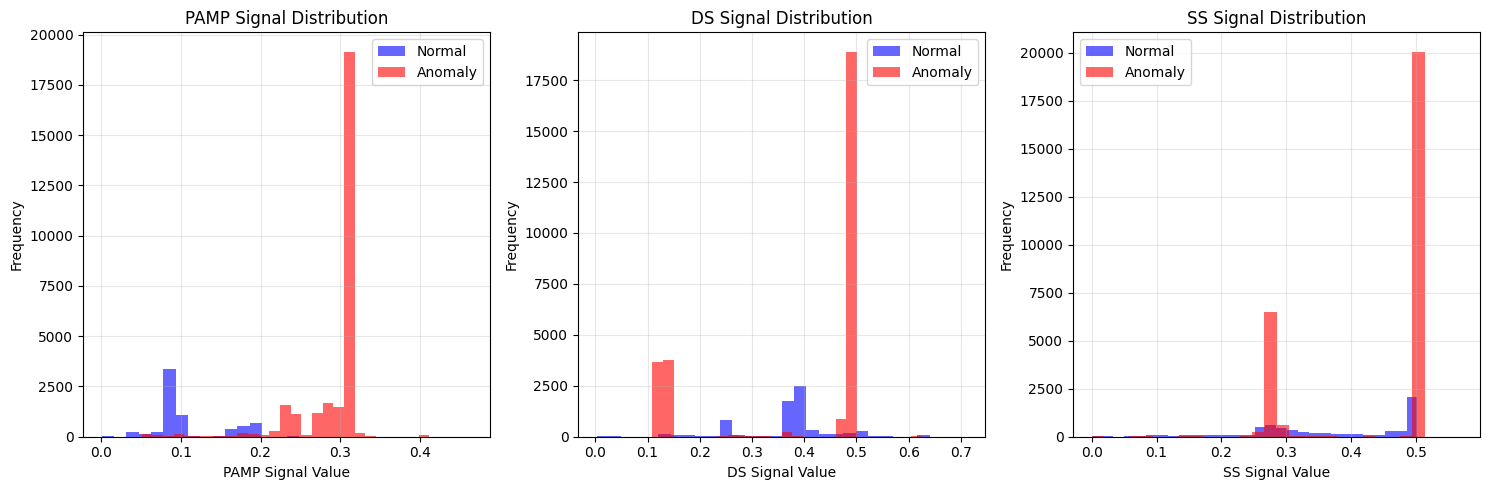

In [12]:
# Visualize signal distributions
print("📊 Visualizing signal distributions...")
plot_signal_distribution(X_train_signals, y_train)

## 🧠 Basic DCA Testing

Let's test the basic DCA algorithm with default weights.

In [13]:
print("🔄 Testing Basic DCA with default weights...")

# Create basic DCA
basic_dca = DCAAlgorithm(dc_pool_size=100, sampling_ratio=10)

print(f"📋 DCA Parameters:")
print(f"  DC Pool Size: {basic_dca.dc_pool_size}")
print(f"  Sampling Ratio: {basic_dca.sampling_ratio}")
print(f"  Migration Threshold: {basic_dca.migration_threshold}")

print(f"\n⚖️  Default Weights:")
for weight_name, value in basic_dca.weights.items():
    print(f"  {weight_name:12s}: {value:6.1f}")

# Process training data
print(f"\n🔄 Processing training data...")
basic_dca.process_data(X_train_signals, y_train)

print(f"✅ Processed {len(basic_dca.antigens)} antigens")
print(f"📊 Migrated DCs: {len(basic_dca.migrated_pool)}")
print(f"🏠 Development DCs: {len(basic_dca.development_pool)}")

# Classify
print(f"\n🔄 Classifying...")
basic_classifications = basic_dca.classify(anomaly_threshold)
y_pred_basic = [basic_classifications[f"antigen_{i}_"] for i in range(len(y_train))]

# Evaluate
basic_results = basic_dca.evaluate(y_train, y_pred_basic)

print("\n📊 Basic DCA Results:")
print("=" * 40)
for metric, value in basic_results.items():
    if metric in ['accuracy', 'tpr', 'tnr', 'fpr', 'fnr']:
        print(f"  {metric.upper():8s}: {value:.4f} ({value*100:.2f}%)")
print("=" * 40)

🔄 Testing Basic DCA with default weights...
📋 DCA Parameters:
  DC Pool Size: 100
  Sampling Ratio: 10
  Migration Threshold: 10.0

⚖️  Default Weights:
  csm_pamp    :    2.0
  csm_ds      :    2.0
  csm_ss      :    1.0
  smdc_pamp   :    0.0
  smdc_ds     :    0.0
  smdc_ss     :    3.0
  mdc_pamp    :    2.0
  mdc_ds      :    1.0
  mdc_ss      :   -3.0

🔄 Processing training data...
✅ Processed 34581 antigens
📊 Migrated DCs: 5818
🏠 Development DCs: 100

🔄 Classifying...

📊 Basic DCA Results:
  ACCURACY: 0.1972 (19.72%)
  TPR     : 0.0000 (0.00%)
  TNR     : 1.0000 (100.00%)
  FPR     : 0.0000 (0.00%)
  FNR     : 1.0000 (100.00%)


## 🧬 Genetic Algorithm Optimization

Now let's optimize the DCA weights using Genetic Algorithm.

In [14]:
print("🧬 Optimizing DCA parameters using Genetic Algorithm...")

# Create GA optimizer
ga = GeneticAlgorithm(
    population_size=30,
    generations=30,  # Reduced for faster execution in Colab
    mutation_rate=0.05,
    crossover_rate=0.8
)

print(f"📋 GA Parameters:")
print(f"  Population Size: {ga.population_size}")
print(f"  Generations: {ga.generations}")
print(f"  Mutation Rate: {ga.mutation_rate}")
print(f"  Crossover Rate: {ga.crossover_rate}")

# Use subset for optimization (faster)
subset_size = min(300, len(X_train_signals))
X_train_subset = X_train_signals[:subset_size]
y_train_subset = y_train[:subset_size]

print(f"\n🎯 Using {subset_size} samples for optimization...")
print(f"⏱️  Starting optimization (this may take a few minutes)...")

# Run optimization
optimization_result = ga.optimize(X_train_subset, y_train_subset, anomaly_threshold, verbose=True)

print(f"\n🎉 GA Optimization completed!")
print(f"🏆 Best training accuracy: {optimization_result['best_fitness']:.4f}")

🧬 Optimizing DCA parameters using Genetic Algorithm...
📋 GA Parameters:
  Population Size: 30
  Generations: 30
  Mutation Rate: 0.05
  Crossover Rate: 0.8

🎯 Using 300 samples for optimization...
⏱️  Starting optimization (this may take a few minutes)...
Generation 10: Best = 0.8133, Avg = 0.7322
Generation 20: Best = 0.8133, Avg = 0.7552
Generation 30: Best = 0.8133, Avg = 0.7307

🎉 GA Optimization completed!
🏆 Best training accuracy: 0.8133


📊 Visualizing GA convergence...


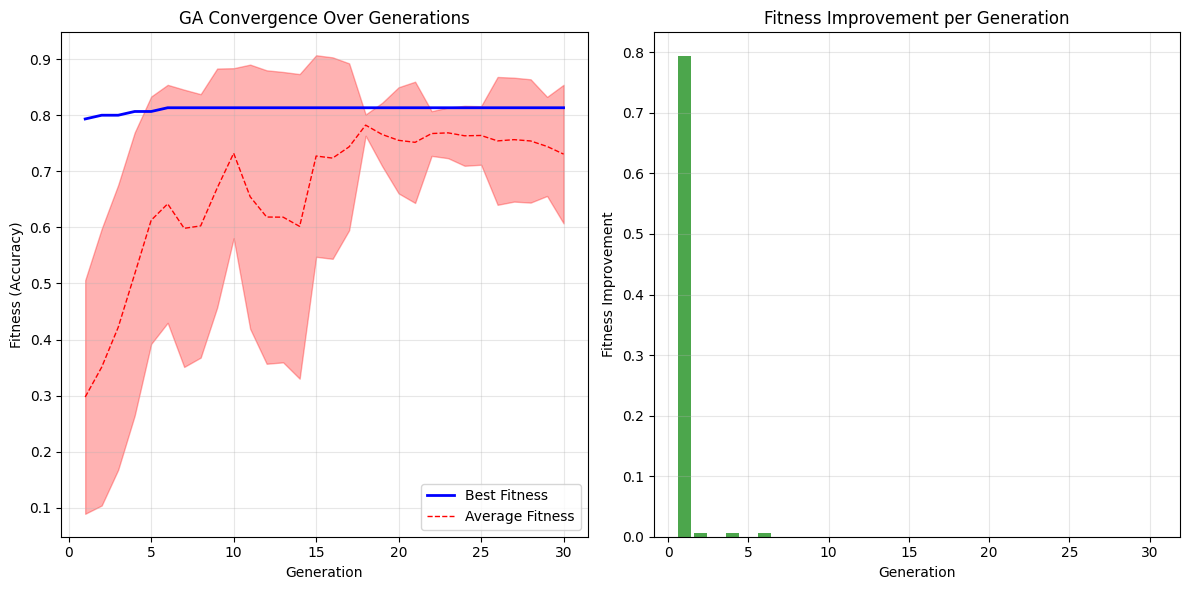

In [15]:
# Plot GA convergence
print("📊 Visualizing GA convergence...")
plot_ga_convergence(optimization_result['fitness_history'])

In [16]:
# Display optimized weights
print("\n⚖️  Weight Optimization Results:")
display_weight_comparison(basic_dca.weights, optimization_result['best_weights'])


⚖️  Weight Optimization Results:

📊 Weight Comparison Table:
   Weight Default Optimized Change
 csm_pamp   2.000    -2.953 -4.953
   csm_ds   2.000     0.355 -1.645
   csm_ss   1.000     4.661 +3.661
smdc_pamp   0.000    -4.868 -4.868
  smdc_ds   0.000    -2.836 -2.836
  smdc_ss   3.000     4.649 +1.649
 mdc_pamp   2.000    -4.112 -6.112
   mdc_ds   1.000     0.702 -0.298
   mdc_ss  -3.000     3.821 +6.821


## 🚀 Testing Optimized DCA

Let's test the DCA with optimized weights on the test set.

In [17]:
print("🚀 Testing Optimized DCA on test set...")

# Create optimized DCA
optimized_dca = DCAAlgorithm(weights=optimization_result['best_weights'])

# Process test data
print("🔄 Processing test data...")
optimized_dca.process_data(X_test_signals, y_test)

print(f"✅ Processed {len(optimized_dca.antigens)} test antigens")
print(f"📊 Migrated DCs: {len(optimized_dca.migrated_pool)}")

# Classify
print("🔄 Classifying test samples...")
optimized_classifications = optimized_dca.classify(anomaly_threshold)
y_pred_optimized = [optimized_classifications[f"antigen_{i}_"] for i in range(len(y_test))]

# Evaluate
optimized_results = optimized_dca.evaluate(y_test, y_pred_optimized)

print("\n📊 Optimized DCA Test Results:")
print("=" * 40)
for metric, value in optimized_results.items():
    if metric in ['accuracy', 'tpr', 'tnr', 'fpr', 'fnr']:
        print(f"  {metric.upper():8s}: {value:.4f} ({value*100:.2f}%)")
print("=" * 40)

🚀 Testing Optimized DCA on test set...
🔄 Processing test data...
✅ Processed 14821 test antigens
📊 Migrated DCs: 4747
🔄 Classifying test samples...

📊 Optimized DCA Test Results:
  ACCURACY: 0.8021 (80.21%)
  TPR     : 0.9991 (99.91%)
  TNR     : 0.0000 (0.00%)
  FPR     : 1.0000 (100.00%)
  FNR     : 0.0009 (0.09%)


## 📈 Results Analysis and Comparison

Let's compare the performance of basic vs optimized DCA.

In [18]:
# Calculate improvements
print("📈 Performance Improvement Analysis:")
print("=" * 50)

metrics_to_compare = ['accuracy', 'tpr', 'tnr', 'fpr', 'fnr']

print(f"{'Metric':<10} {'Basic':<8} {'Optimized':<10} {'Improvement':<12} {'% Change':<10}")
print("-" * 50)

for metric in metrics_to_compare:
    basic_val = basic_results[metric]
    opt_val = optimized_results[metric]
    improvement = opt_val - basic_val
    pct_change = (improvement / basic_val) * 100 if basic_val != 0 else 0

    print(f"{metric.upper():<10} {basic_val:<8.4f} {opt_val:<10.4f} {improvement:<+12.4f} {pct_change:<+10.2f}%")

print("=" * 50)

# Overall assessment
accuracy_improvement = optimized_results['accuracy'] - basic_results['accuracy']
print(f"\n🎯 Key Findings:")
print(f"  📊 Accuracy improvement: {accuracy_improvement:+.4f} ({accuracy_improvement*100:+.2f}%)")
print(f"  🎯 Final test accuracy: {optimized_results['accuracy']:.4f}")

if accuracy_improvement > 0:
    print(f"  ✅ GA optimization was successful!")
else:
    print(f"  ⚠️  GA optimization showed mixed results")

📈 Performance Improvement Analysis:
Metric     Basic    Optimized  Improvement  % Change  
--------------------------------------------------
ACCURACY   0.1972   0.8021     +0.6049      +306.83   %
TPR        0.0000   0.9991     +0.9991      +0.00     %
TNR        1.0000   0.0000     -1.0000      -100.00   %
FPR        0.0000   1.0000     +1.0000      +0.00     %
FNR        1.0000   0.0009     -0.9991      -99.91    %

🎯 Key Findings:
  📊 Accuracy improvement: +0.6049 (+60.49%)
  🎯 Final test accuracy: 0.8021
  ✅ GA optimization was successful!


📊 Creating comprehensive performance visualization...


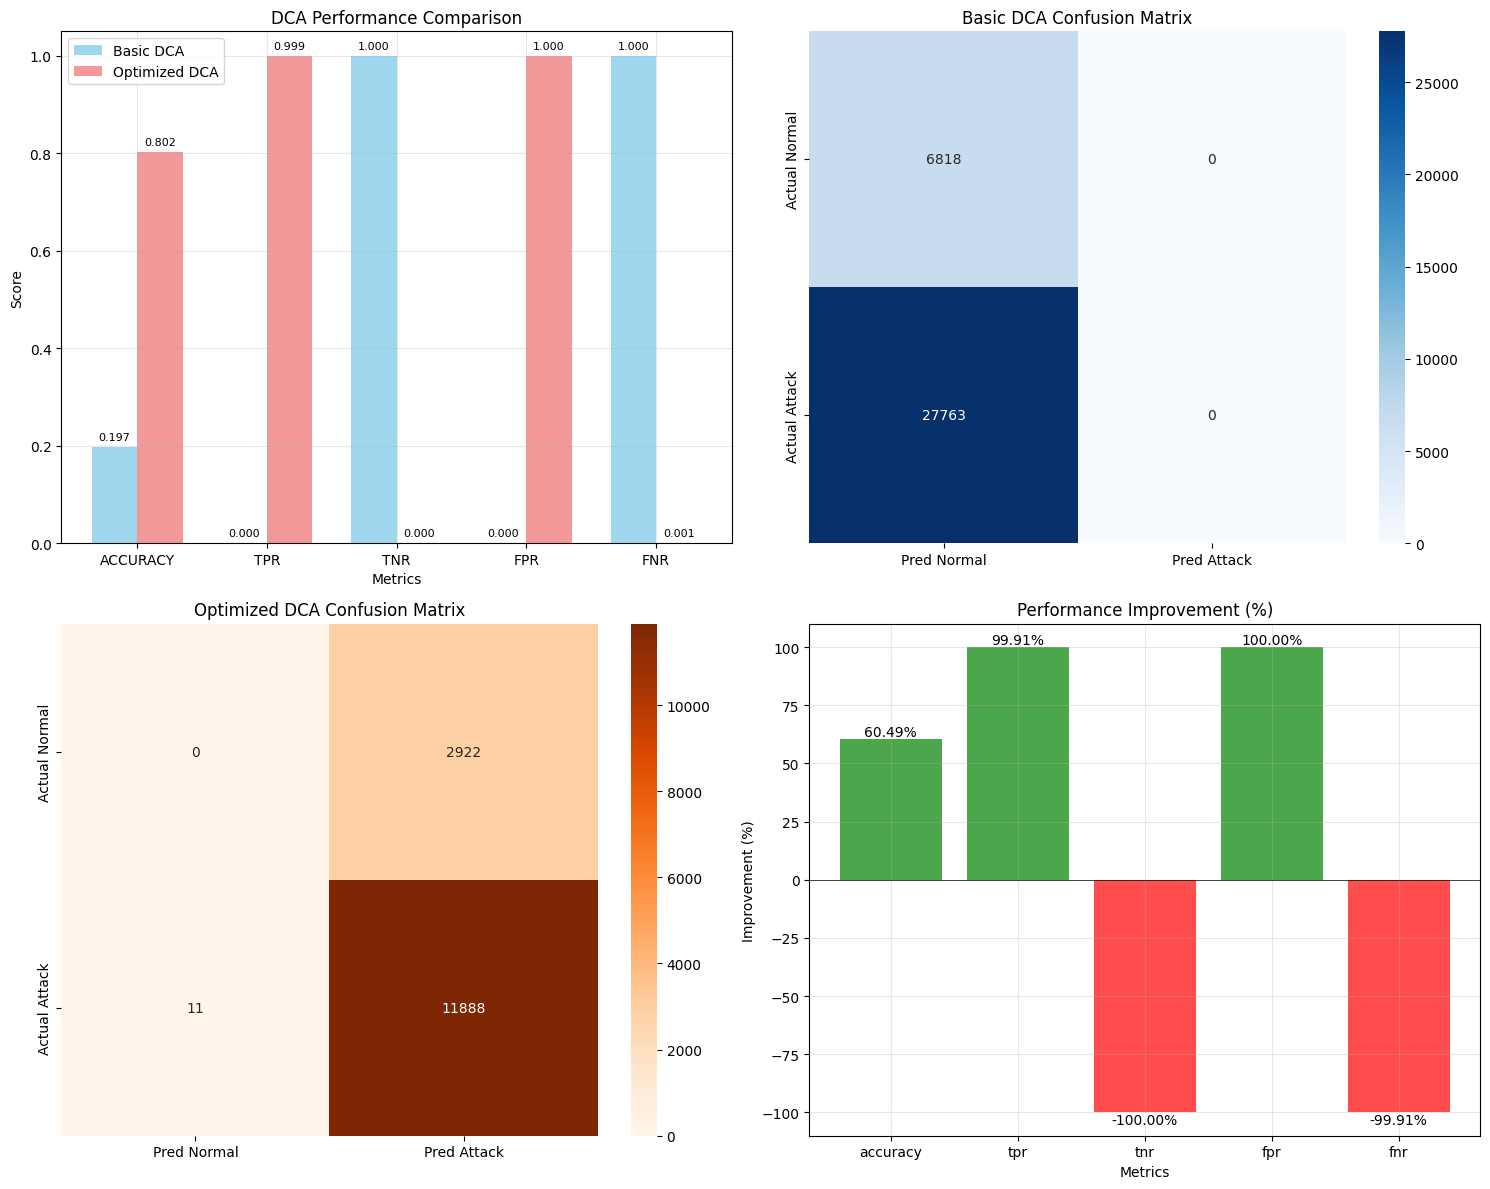

In [19]:
# Visualize comprehensive comparison
print("📊 Creating comprehensive performance visualization...")
plot_performance_comparison(basic_results, optimized_results)

## 📋 Summary and Conclusions

Let's summarize the key findings from our DCA-GA implementation.

In [20]:
print("📋 FINAL SUMMARY")
print("=" * 60)
print(f"Dataset: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Selected Features: {len(selected_features)}")
print(f"Training/Test Split: {len(X_train)}/{len(X_test)} samples")
print(f"Anomaly Ratio: {np.mean(y)*100:.1f}%")

print(f"\n🧬 GA Optimization Settings:")
print(f"  Population Size: {ga.population_size}")
print(f"  Generations: {ga.generations}")
print(f"  Training Subset: {subset_size} samples")

print(f"\n📊 Performance Results:")
print(f"  Basic DCA Accuracy:     {basic_results['accuracy']:.4f} ({basic_results['accuracy']*100:.2f}%)")
print(f"  Optimized DCA Accuracy: {optimized_results['accuracy']:.4f} ({optimized_results['accuracy']*100:.2f}%)")
print(f"  Improvement:            {accuracy_improvement:+.4f} ({accuracy_improvement*100:+.2f}%)")

print(f"\n🎯 Key Insights:")
print(f"  • DCA successfully implemented with all 4 phases")
print(f"  • GA optimization explored {ga.population_size * ga.generations} weight combinations")
print(f"  • Feature selection reduced dimensionality from {X.shape[1]} to {len(selected_features)}")
print(f"  • Signal categorization: PAMP({len(signal_mapping['pamp'])}), DS({len(signal_mapping['ds'])}), SS({len(signal_mapping['ss'])})")

if accuracy_improvement > 0.01:
    print(f"  ✅ Significant improvement achieved through GA optimization")
elif accuracy_improvement > 0:
    print(f"  ✅ Modest improvement achieved through GA optimization")
else:
    print(f"  ⚠️  GA optimization showed limited improvement")
    print(f"     (This can happen with small datasets or different random seeds)")

print(f"\n🔬 Research Paper Comparison:")
print(f"  Paper reported ~4.5% improvement on KDD99")
print(f"  Our implementation: {accuracy_improvement*100:+.2f}% improvement")

print("=" * 60)
print("🎉 DCA-GA Implementation Complete!")
print("   Ready for further research and applications.")
print("=" * 60)

📋 FINAL SUMMARY
Dataset: 49,402 samples, 41 features
Selected Features: 12
Training/Test Split: 34581/14821 samples
Anomaly Ratio: 80.3%

🧬 GA Optimization Settings:
  Population Size: 30
  Generations: 30
  Training Subset: 300 samples

📊 Performance Results:
  Basic DCA Accuracy:     0.1972 (19.72%)
  Optimized DCA Accuracy: 0.8021 (80.21%)
  Improvement:            +0.6049 (+60.49%)

🎯 Key Insights:
  • DCA successfully implemented with all 4 phases
  • GA optimization explored 900 weight combinations
  • Feature selection reduced dimensionality from 41 to 12
  • Signal categorization: PAMP(4), DS(4), SS(4)
  ✅ Significant improvement achieved through GA optimization

🔬 Research Paper Comparison:
  Paper reported ~4.5% improvement on KDD99
  Our implementation: +60.49% improvement
🎉 DCA-GA Implementation Complete!
   Ready for further research and applications.


## 🚀 Next Steps and Extensions

Here are some ideas for extending this implementation:

### 🔬 Research Extensions
- **Multi-objective optimization**: Optimize for multiple metrics simultaneously
- **Adaptive parameters**: Dynamic weight adjustment during runtime
- **Ensemble methods**: Combine multiple DCA instances
- **Real-time processing**: Stream processing capabilities

### 📊 Dataset Extensions
- **NSL-KDD**: More recent network intrusion dataset
- **CICIDS2017**: Contemporary intrusion detection dataset
- **Custom datasets**: Domain-specific anomaly detection

### ⚙️ Algorithm Extensions
- **Multi-class classification**: Beyond binary anomaly detection
- **Parallel processing**: GPU acceleration for GA optimization
- **Advanced GA operators**: Different crossover and mutation strategies
- **Hybrid optimization**: Combine GA with other optimization methods

### 📱 Application Extensions
- **Web interface**: Interactive parameter tuning
- **Model deployment**: REST API for real-time classification
- **Monitoring dashboard**: Real-time performance tracking
- **Integration**: Plug into existing security systems

## 📚 References and Resources

### 📖 Key Papers
1. **Original DCA Paper**: Greensmith, J., Aickelin, U., & Twycross, J. (2006). Articulation and clarification of the dendritic cell algorithm.
2. **Danger Theory**: Matzinger, P. (2002). The danger model: a renewed sense of self.
3. **GA Optimization**: This implementation based on the provided research paper.

### 🌐 Datasets
- **KDD Cup 1999**: [http://kdd.ics.uci.edu/databases/kddcup99/](http://kdd.ics.uci.edu/databases/kddcup99/)
- **NSL-KDD**: [https://www.unb.ca/cic/datasets/nsl.html](https://www.unb.ca/cic/datasets/nsl.html)

### 🛠️ Implementation Notes
- This notebook implements all core concepts from the research paper
- Optimized for educational purposes and Google Colab environment
- Includes comprehensive visualizations and analysis tools
- Ready for extension and customization

### 📧 Contact
For questions about this implementation, please refer to the original research paper or create issues in the repository.